# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 10     |  |
| :-------------|:-------------|
| Daniel Roelse | 6527892 |
| Vladimir Ristic| 6507468 |
| Thijn Holswilder | 6536387 |

## Opdracht 1: Planning.

| Planning Groep: 10     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11.30 | Thijn |
| ontwerp-eis berekenen| 12.00 | Daniel & Vladimir |
| Sanity check| 12.30 | hele groep |
| Pauze 1| 12.30-13.30 | hele groep |
| Eerste ontwerp af | 14.15 | hele groep |
| Simulatie | 14.45 | hele groep |
| iteratie & eindontwerp | 16.30 | hele groep |
| Feedback & opruimen | 17.00 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 3 |
| hoe lang voor één meting | 2 minuten |
| verwacht nauwkeurigheid meting | 0.1 meter |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
f_0 = 5 # frequentie van de vloer in Hz
omega = 2 * math.pi * f_0
dempingsfactor = 3 # dempingsfactor van de vloer
omega_0 = math.sqrt(omega**2/ (dempingsfactor+1 )) # kantelfrequentie in rad/s
print(f"De benodigde kantelfrequentie is: {omega_0:.2f} rad/s")

De benodigde kantelfrequentie is: 15.71 rad/s


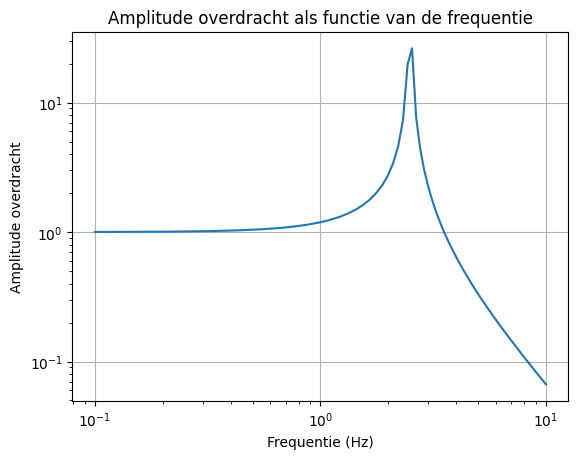

In [3]:
# Voeg hier je plot in.
f_0_plot = np.linspace(0.1, 10, 90)
omega_plot = 2 * math.pi * f_0_plot

demping = np.abs(1 / (1 - (omega_plot ** 2 / omega_0 ** 2)))
plt.loglog(f_0_plot, demping)
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Amplitude overdracht')
plt.title('Amplitude overdracht als functie van de frequentie')
plt.grid()
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
delta_x = g/omega_0**2
print(delta_x)

0.039758432461253344


## Opdracht 3: Plot de grafiek.

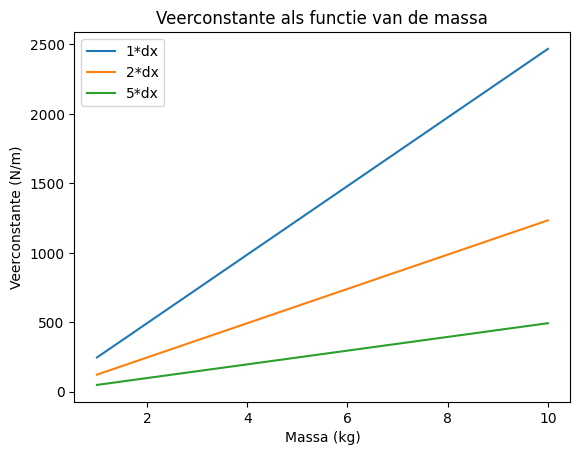

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().
m = np.linspace(1,10,100)
C = m*g/ delta_x
plt.plot(m,C, label='1*dx')
plt.plot(m,C/2, label='2*dx')
plt.plot(m,C/5, label='5*dx')
plt.legend()
plt.xlabel('Massa (kg)')
plt.ylabel('Veerconstante (N/m)')
plt.title('Veerconstante als functie van de massa')
plt.savefig('veerconstante_plot.png')
plt.show()


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- massa groter maken
- veerconstante kleiner maken

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 0.05 +/- 0.005 m
Onze minimale $\Delta x$ is ongeveer 0.04 m, dus we willen een $\Delta x$ van 0.05 m aanhouden zodat we zeker weten dat we aan de eis voldoen.

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="Schets_ontwerp_nieuw.jpg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?
**0.1 m**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**Ja**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**1.5 m, er zit een grens aan de elastiek**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Ja**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

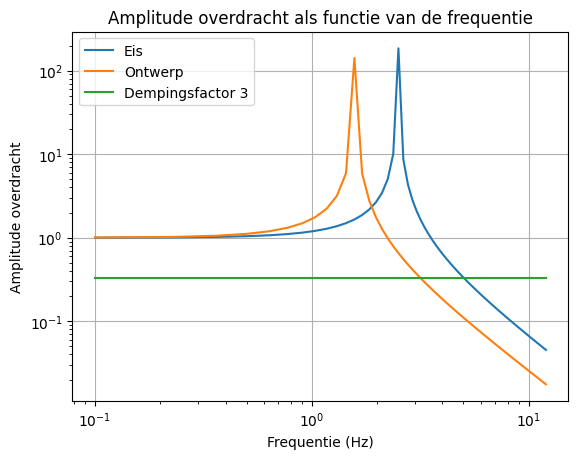

In [6]:
f_0_plot = np.linspace(0.1, 12, 90)
omega_plot = 2 * math.pi * f_0_plot
omega_0_plot = np.sqrt(omega_plot**2/ (dempingsfactor+1 ))
dx = 0.1 # m
omega_0_ontwerp = np.sqrt(g/dx)
demping_ontwerp = np.abs(1 / (1 - (omega_plot ** 2 / omega_0_ontwerp ** 2)))
demping = np.abs(1 / (1 - (omega_plot ** 2 / omega_0 ** 2)))

plt.loglog(f_0_plot, demping, label='Eis')
plt.loglog(f_0_plot, demping_ontwerp, label='Ontwerp')
plt.loglog(f_0_plot, np.linspace(1/3, 1/3, len(f_0_plot)), label='Dempingsfactor 3')
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Amplitude overdracht')
plt.title('Amplitude overdracht als functie van de frequentie')
plt.legend()
plt.grid()
plt.show()

## Opdracht 7: Plotten maar

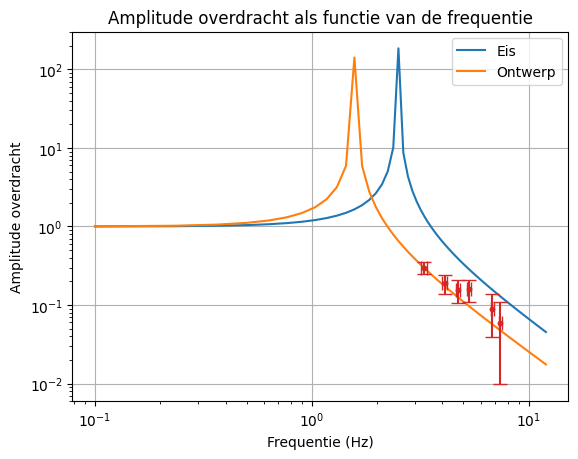

In [7]:
frequentie = np.array([5.3,6.8,7.4,3.3,4.1,4.7])
A1 = np.array([6.3,6.14,3.01,4.26,5.1,4.9])
A2 = np.array([1.01,0.55,0.18,1.27,0.96,0.77])
u_frequentie = 0.1
u_amplitude = 0.05
u_A1 = np.array([0.05,0.05,0.05])
u_A2 = np.array([0.05,0.05,0.05])
plt.plot(f_0_plot, demping, label='Eis')
plt.plot(f_0_plot, demping_ontwerp, label='Ontwerp')
plt.xscale('log')
plt.yscale('log')
amplitude_overdacht = A2/A1
#u_ampiltude_oud = amplitude_overdacht * np.sqrt((u_A1/A1)**2 + (u_A2/A2)**2)
plt.plot(frequentie, amplitude_overdacht,'.')

plt.errorbar(frequentie, amplitude_overdacht, xerr=u_frequentie, yerr=u_amplitude, fmt='.', capsize=5)
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Amplitude overdracht')
plt.title('Amplitude overdracht als functie van de frequentie')
plt.legend()
plt.grid()
plt.show()

## Discussie ##
De metingen met frequenties kleiner dan w_0 van het ontwerp hadden een te grote onzekerheid om betrouwbare en nuttige te plotten. Aanvankelijk bij ons eerste ontwerp hadden we een onnauwkeurige amplitude die werdt veroorzaakt door dat de sensor ook een kleine verplaatsing in de x en y richting had. Dit hebben wij daarna aangepast door het ontwerp stabieler te maken waardoor we daarna alleen een amplitude in de z richting hadden.
Als we een langere arm hadden gehad hadden we lagere frequenties kunnen meten waarder er links van de w_0 we ook meetpunten hadden gehad. 

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

Leerdoel 1: Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.

We hebben leerdoel 1 behaald omdat we de omega_0 hebben afgeleid via de differentiaalvergelijking. Daarna hebben we via $\omega _0$ = $\sqrt{\frac{g}{\Delta{x}}}$ achterhaald dat de parameters waarmee we konden werken de $\Delta x $ was. De $\Delta x $ was afhankelijk van de veerconstante C en de massa van het systeem m.

Leerdoel 2: Op basis van een differentiaalvergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp.

Onze eis was dat wij onze $\Delta x$ minimaal op onze berekende 0.04 m moesten hebben. Deze $\Delta x$ is groot te krijgen door de parameters hieronder aan te passen. Door dus de parameters van C en m slim te kiezen hebben we dat kunnen vertalen in ons fysieke ontwerp voor het behalen van onze minimale $\Delta x$ 0.04 m.

In [8]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
delta_x = g/omega_0**2
print(delta_x)

0.039758432461253344


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- massa groter maken
- veerconstante kleiner maken

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 0.05 +/- 0.005 m
Onze minimale $\Delta x$ is ongeveer 0.04 m, dus we willen een $\Delta x$ van 0.05 m aanhouden zodat we zeker weten dat we aan de eis voldoen.